In [1]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import os

In [2]:
import sys
sys.path.append("utils")
from torch_utils import *

In [3]:
def show_normalized_image(img):
    """
    img: torch tensor (3, H, W), normalized using ImageNet mean/std.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # Unnormalize
    img_unnorm = img * std + mean
    img_unnorm = img_unnorm.clamp(0, 255).type(torch.uint8)  # keep values in valid range

    # Convert to numpy for plt
    img_np = img_unnorm.permute(1, 2, 0).numpy()

    img_np = np.ascontiguousarray(img_np)

    return img_np

In [3]:
trained_model.load_state_dict(torch.load("11weight.pt", weights_only=True))

NameError: name 'trained_model' is not defined

In [7]:
ds_path = "dataset/OPA/new_OPA/"
dataset_path = ds_path
label_dir = dataset_path + "new_alt_test_label.csv"
img_dir = dataset_path + "background"
obj_dir = dataset_path + "foreground"
transform = vit_transform

In [8]:
test_dataset = OPADataset_2(label_dir, img_dir, obj_dir, transform=vit_transform_2, target_transform=None, obj_transform=vit_transform_2)

In [9]:
test_dataloader = DataLoader(test_dataset, batch_size=5)

In [3]:
model = fusion_v3(55, 16)

In [4]:
model.load_state_dict(torch.load("checkpoint.pt", weights_only=True))

<All keys matched successfully>

In [5]:
model.to(gpu)

fusion_v3(
  (vit): ViTEncoder(
    (vit): VisionTransformer(
      (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (encoder): Encoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (layers): Sequential(
          (encoder_layer_0): EncoderBlock(
            (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (self_attention): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
            )
            (dropout): Dropout(p=0.0, inplace=False)
            (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): MLPBlock(
              (0): Linear(in_features=768, out_features=3072, bias=True)
              (1): GELU(approximate='none')
              (2): Dropout(p=0.0, inplace=False)
              (3): Linear(in_features=3072, out_features=768, bias=True)
              (4): Dropout(p=0.0, inplace=False)
            )
          )
     

In [10]:
X,y,n = None,None,None
for X,y,n in test_dataloader:
    break

In [9]:
y

tensor([[[158.4000, 242.4000, 315.6000,  92.4000],
         [251.4000, 226.2000, 379.2000, 104.4000],
         [     inf,      inf,      inf,      inf],
         ...,
         [     inf,      inf,      inf,      inf],
         [     inf,      inf,      inf,      inf],
         [     inf,      inf,      inf,      inf]],

        [[274.2000, 116.4000, 306.6000,  45.6000],
         [203.4000, 235.8000, 235.2000, 165.6000],
         [114.6000, 167.4000, 147.0000,  96.6000],
         ...,
         [     inf,      inf,      inf,      inf],
         [     inf,      inf,      inf,      inf],
         [     inf,      inf,      inf,      inf]],

        [[267.0000, 168.0000, 336.0000, 154.2000],
         [ 64.2000,  15.6000, 133.2000,   1.8000],
         [ 72.6000, 141.0000, 141.6000, 127.2000],
         ...,
         [     inf,      inf,      inf,      inf],
         [     inf,      inf,      inf,      inf],
         [     inf,      inf,      inf,      inf]],

        [[310.8000, 248.4000, 375.

In [11]:
y.shape

torch.Size([5, 55, 4])

In [13]:
y[0]

tensor([[158.4000, 242.4000, 315.6000,  92.4000],
        [251.4000, 226.2000, 379.2000, 104.4000],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],
        [     inf,      inf,      inf,      inf],


In [22]:
y[(~torch.isinf(y))]

tensor([158.4000, 242.4000, 315.6000,  92.4000, 251.4000, 226.2000, 379.2000,
        104.4000, 274.2000, 116.4000, 306.6000,  45.6000, 203.4000, 235.8000,
        235.2000, 165.6000, 114.6000, 167.4000, 147.0000,  96.6000, 226.2000,
        116.4000, 258.6000,  45.6000,  28.8000, 203.4000,  61.2000, 132.6000,
         63.0000, 189.6000,  94.8000, 119.4000, 193.2000, 240.0000, 225.6000,
        169.2000, 136.2000, 170.4000, 168.6000,  99.6000, 267.0000, 168.0000,
        336.0000, 154.2000,  64.2000,  15.6000, 133.2000,   1.8000,  72.6000,
        141.0000, 141.6000, 127.2000, 211.8000, 196.8000, 280.8000, 183.0000,
        279.0000,  87.0000, 348.0000,  73.2000, 195.0000, 154.2000, 264.0000,
        140.4000, 310.8000, 248.4000, 375.6000, 144.0000, 100.8000, 250.2000,
        165.6000, 145.8000,  90.0000, 237.0000, 204.0000,  53.4000,  43.2000,
        194.4000, 157.2000,  10.8000, 263.4000, 115.2000, 309.0000,  41.4000,
        298.2000, 160.2000, 381.0000,  26.4000, 319.2000, 150.00

In [13]:
print("parameters:", sum(p.numel() for p in model.parameters())) 

parameters: 126641444


In [11]:
o = model(X)

In [15]:
o.shape

torch.Size([5, 55, 4])

In [12]:
o

tensor([[[ -3.1558, 334.5993, 262.2524,  43.3684],
         [145.0997, 236.1017, 292.6109, 114.7752],
         [ 12.8981, 324.4918, 251.9028,  65.3402],
         ...,
         [ 47.0821, 278.9035, 173.8550, 140.2782],
         [ -1.8698, 334.0002, 262.0438,  44.7015],
         [ 46.8166, 279.0854, 173.9539, 140.0042]],

        [[ -6.7897, 335.5919, 260.5644,  40.7328],
         [119.4833, 230.0427, 265.6345,  94.6784],
         [ 76.8805, 278.3989, 202.6352, 155.2970],
         ...,
         [ 47.3429, 270.9151, 156.4355, 148.8687],
         [ -6.7943, 335.5915, 260.5577,  40.7288],
         [ 47.0675, 271.1076, 156.5452, 148.5815]],

        [[ -7.2011, 335.0796, 258.5798,  41.4844],
         [122.1741, 234.1618, 276.1685,  93.5342],
         [ 77.2002, 277.1049, 199.7911, 157.1058],
         ...,
         [ 48.9818, 269.9733, 155.8134, 150.8723],
         [ -7.0976, 334.9724, 258.4384,  41.6357],
         [ 48.7079, 270.1646, 155.9216, 150.5872]],

        [[ -7.6691, 336.2531, 261.

In [13]:
def get_category(fg_name):
    categories = os.listdir("dataset/OPA/new_OPA/foreground")
    for cat in categories:
        if fg_name + ".jpg" in os.listdir("dataset/OPA/new_OPA/foreground/"+cat):
            return cat

In [26]:
o

tensor([[[240.8011, -77.7723,  91.9308, 432.3157],
         [240.5733, -77.5064,  91.7650, 432.1741],
         [199.8265, -55.1359, 108.7008, 411.4157],
         ...,
         [162.0383, -34.2893, 104.8114, 379.2816],
         [161.5635, -34.1340, 105.0980, 378.9154],
         [240.6028, -77.5331,  91.5689, 432.1774]],

        [[241.6367, -77.7549,  89.1789, 431.7573],
         [240.8633, -77.0965,  88.9936, 431.3511],
         [200.4458, -55.0069, 107.3477, 411.7017],
         ...,
         [164.0056, -35.1233, 104.0924, 380.9155],
         [163.0894, -34.3881, 103.2920, 379.8369],
         [242.6372, -78.4840,  89.2384, 432.2083]],

        [[245.6093, -80.4303,  88.1918, 432.9163],
         [245.4117, -80.1913,  88.0367, 432.7912],
         [202.3286, -55.9875, 106.8386, 413.0006],
         ...,
         [164.7767, -35.4971, 103.8533, 381.5665],
         [165.0997, -35.7175, 103.8669, 381.8755],
         [246.2407, -80.8324,  87.8452, 433.0617]],

        [[245.1394, -80.0687,  88.

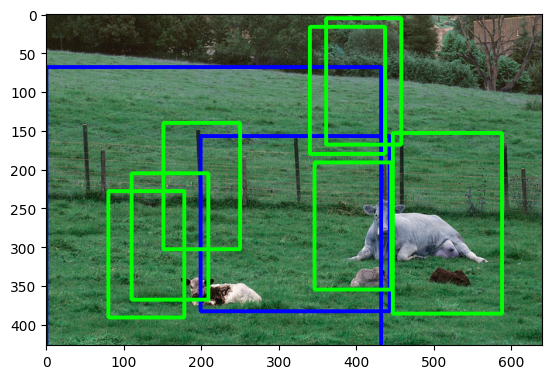

In [31]:
for i in range(len(X)):
    q = 640/384
    pred = o[i]
    label = y[i]
    fg_name, bg_name = n[i].split("c")
    cat = get_category(fg_name)
    bg_img = cv2.imread("dataset/OPA/new_OPA/background/" + cat + "/" + bg_name + ".jpg")
    for p in pred[:2]:
        xmin, ymin, xmax, ymax = p
        xmin, ymin, xmax, ymax = [x.item() for x in [xmin, ymin, xmax, ymax]]
        xmin, ymin, xmax, ymax = [x * q for x in [xmin, ymin, xmax, ymax]]
        xmin, ymin, xmax, ymax = [int(x) for x in [xmin, ymin, xmax, ymax]]
        xmin, ymin, xmax, ymax = [max(x, 0) for x in [xmin, ymin, xmax, ymax]]
        bg_img = cv2.rectangle(bg_img,(xmin, ymax),(xmax, ymin),(0, 0, 255), 3)
    for s_label in y[i]:
        xmin, ymin, xmax, ymax = s_label
        xmin, ymin, xmax, ymax = [x.item() for x in [xmin, ymin, xmax, ymax]]
        if xmin == float("inf"):
            continue

        xmin, ymin, xmax, ymax = [x * q for x in [xmin, ymin, xmax, ymax]]
        xmin, ymin, xmax, ymax = [int(x) for x in [xmin, ymin, xmax, ymax]]
        bg_img = cv2.rectangle(bg_img,(xmin, ymax),(xmax, ymin),(0, 255, 0), 3)
    plt.imshow(bg_img)

In [14]:
vit.to(gpu)
en.to(gpu)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [9]:
X.shape

torch.Size([5, 6, 384, 384])

In [29]:
vit._process_input(X[:, :3, :, :]).shape

torch.Size([5, 576, 768])

In [8]:
class ViTExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = torchvision.models.vit_b_16(weights="IMAGENET1K_SWAG_E2E_V1")

    def forward(self, x):
        x = self.vit._process_input(x)
        n = x.shape[0]

        # Expand the class token to the full batch
        batch_class_token = self.vit.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)

        x = self.vit.encoder(x)

        # Classifier "token" as used by standard language architectures
        # x = x[:, 0]

        return x

In [33]:
class ENEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.en = torchvision.models.efficientnet_v2_s(weights="IMAGENET1K_V1")

    def forward(self, x):
        x = self.en.features(x)
        return x
        

In [34]:
en_en = ENEncoder()
en_en.to(gpu)

ENEncoder(
  (en): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): FusedMBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (1): BatchNorm2d(24, eps

In [40]:
en_out = en_en(fg)

In [14]:
em = nn.Embedding(10, 768)

In [23]:
em.weight.unsqueeze(1).repeat(1, 5, 1).shape

torch.Size([10, 5, 768])

In [41]:
flatten = torch.flatten(en_out,start_dim=-2)

In [43]:
flatten.shape

torch.Size([5, 1280, 144])

In [44]:
permuted = torch.permute(flatten, (0,2,1))

In [45]:
permuted.shape

torch.Size([5, 144, 1280])

In [48]:
linear_layer = nn.Linear(1280, 768)
linear_layer.to(gpu)

Linear(in_features=1280, out_features=768, bias=True)

In [49]:
o = linear_layer(permuted)

In [50]:
o.shape

torch.Size([5, 144, 768])

In [9]:
vit_ex = ViTExtractor()
vit_ex.to(gpu)

ViTExtractor(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): Laye

In [21]:
batch = vit_ex(bg)

In [38]:
batch.shape

torch.Size([5, 577, 768])

In [22]:
patch = batch[1]

In [28]:
batch

tensor([[[ 0.5144,  0.1544, -0.0441,  ...,  2.6422, -1.6075,  1.4741],
         [ 0.5028, -0.0419,  2.7924,  ...,  0.6704, -0.9100,  0.0477],
         [ 0.3678,  0.0715,  0.1868,  ..., -0.3498,  0.3592,  0.4693],
         ...,
         [-2.2214, -0.9870, -1.2519,  ...,  1.9529, -3.1672,  1.2654],
         [-2.2428, -1.0171, -1.4391,  ...,  1.7412, -3.3743,  1.1378],
         [-1.5207, -1.1162, -0.9943,  ...,  2.0421, -2.8986,  1.3038]],

        [[ 1.2518, -0.3248, -0.6136,  ...,  1.0845, -1.1455,  1.5585],
         [ 0.1601, -0.0498, -1.2721,  ..., -2.1127,  1.4908,  0.4086],
         [ 0.0493,  0.2017, -0.7624,  ...,  0.6942, -1.5263,  0.9497],
         ...,
         [-2.0345, -1.4067, -1.8239,  ...,  1.2520, -2.0581,  1.4017],
         [-2.0263, -1.3811, -1.8645,  ...,  1.0901, -2.0977,  1.3113],
         [-1.1637, -1.2908, -1.1040,  ...,  1.2119, -2.2670,  1.1568]],

        [[ 0.4814, -0.3817,  0.3398,  ...,  2.2676, -1.1604,  0.7076],
         [ 0.5117,  0.1469,  0.1797,  ..., -0

In [11]:
bg = X[:, :3, :, :]
fg = X[:, 3:, :, :]

#bg = vit(bg)
#fg = en(fg)

In [ ]:
en.forward

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [20]:
vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [18]:
X.shape

torch.Size([5, 6, 384, 384])

In [ ]:
vit.forward

In [16]:
bg.shape

torch.Size([5, 1000])

In [17]:
fg.shape

torch.Size([5, 1280])

In [10]:
model.to(gpu)
trained_model.to(gpu)
model.eval()
trained_model.eval()
model_pred = model(X)
trained_pred = trained_model(X)

In [11]:
model_pred

tensor([[ -119.9347,   -87.3314,  -124.9103,   -77.3079],
        [  -76.4481,   -61.3541,   -34.9552,   -54.2208],
        [  -98.3534,  -218.9025,   -66.7009,   -46.1859],
        [ -285.3290, -1111.5757,  -199.7971,  -216.9403],
        [ -147.6469,  -155.9795,  -131.2493,   -60.0803]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [24]:
y[0][2][1].item() == float('inf')

True

In [8]:
import torchvision

In [14]:
boxes1 = torch.tensor([1, 2, 3, 4])
x1, y1, x2, y2 = boxes1.unbind(dim=-1)

In [19]:
torch.max(x1, x2)

tensor(3)

In [18]:
torch.max(x1, x2)[False]

tensor([], dtype=torch.int64)

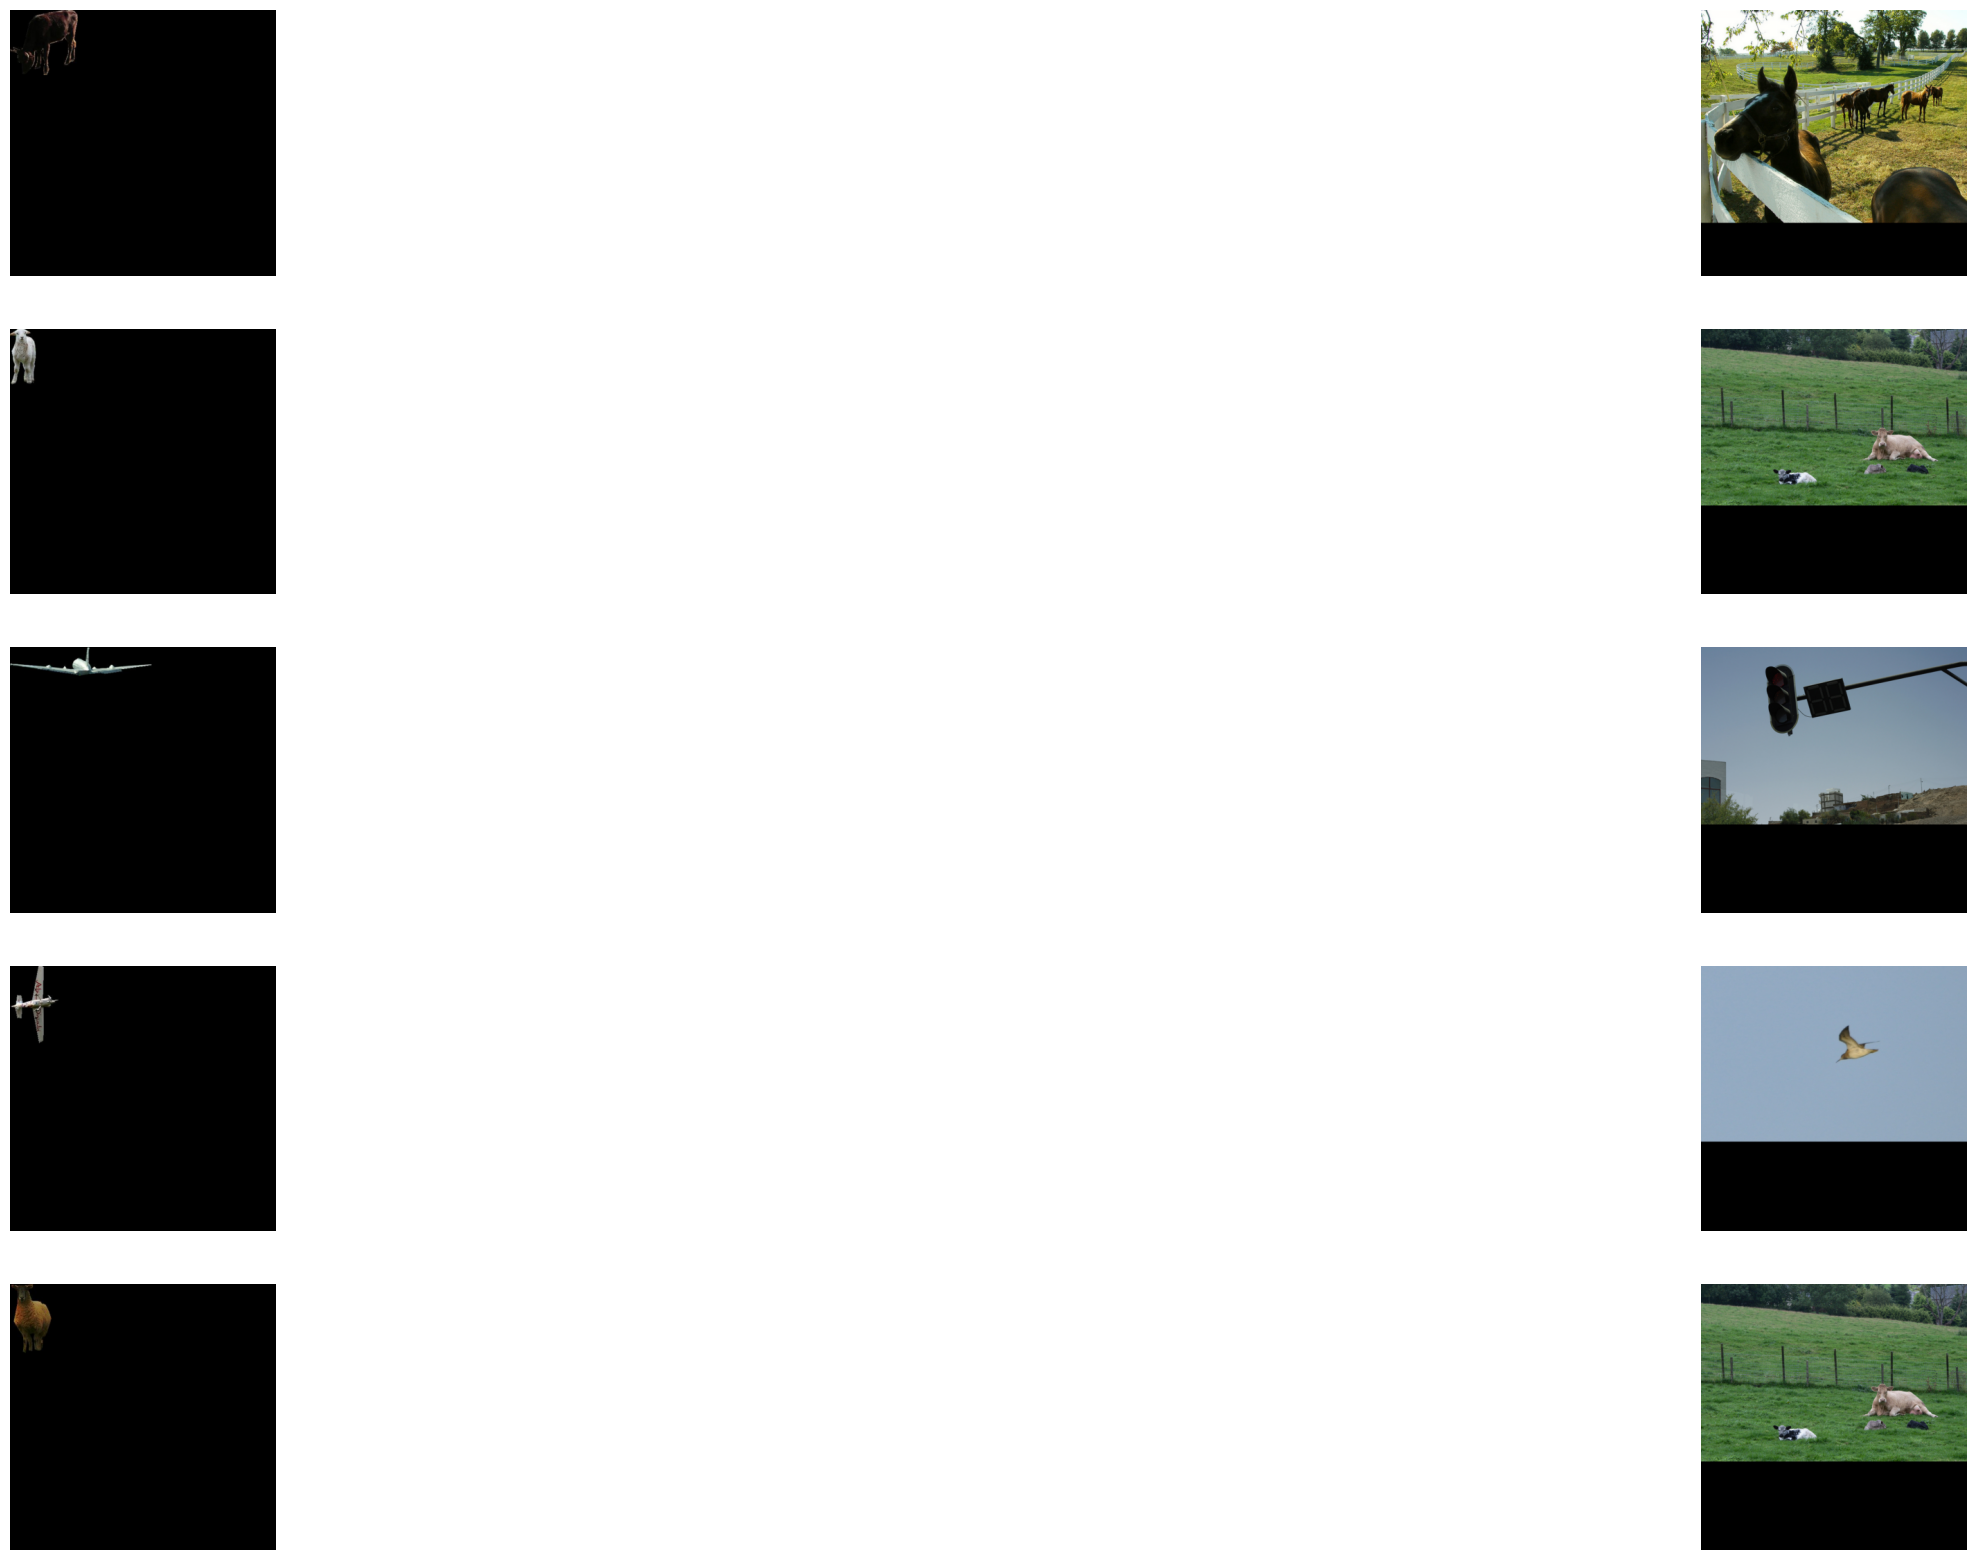

In [14]:
# visualize inputs after pre processed
nrow = len(X)
ncol = 2
idx = 0
fig, axis = plt.subplots(nrow,ncol,figsize=(40,20))
for x in X:
    fg_img = x[3:, :, :]
    bg_img = x[:3, :, :]
    bg_img = show_normalized_image(bg_img.cpu())
    fg_img = show_normalized_image(fg_img.cpu())

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(fg_img)

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(bg_img)

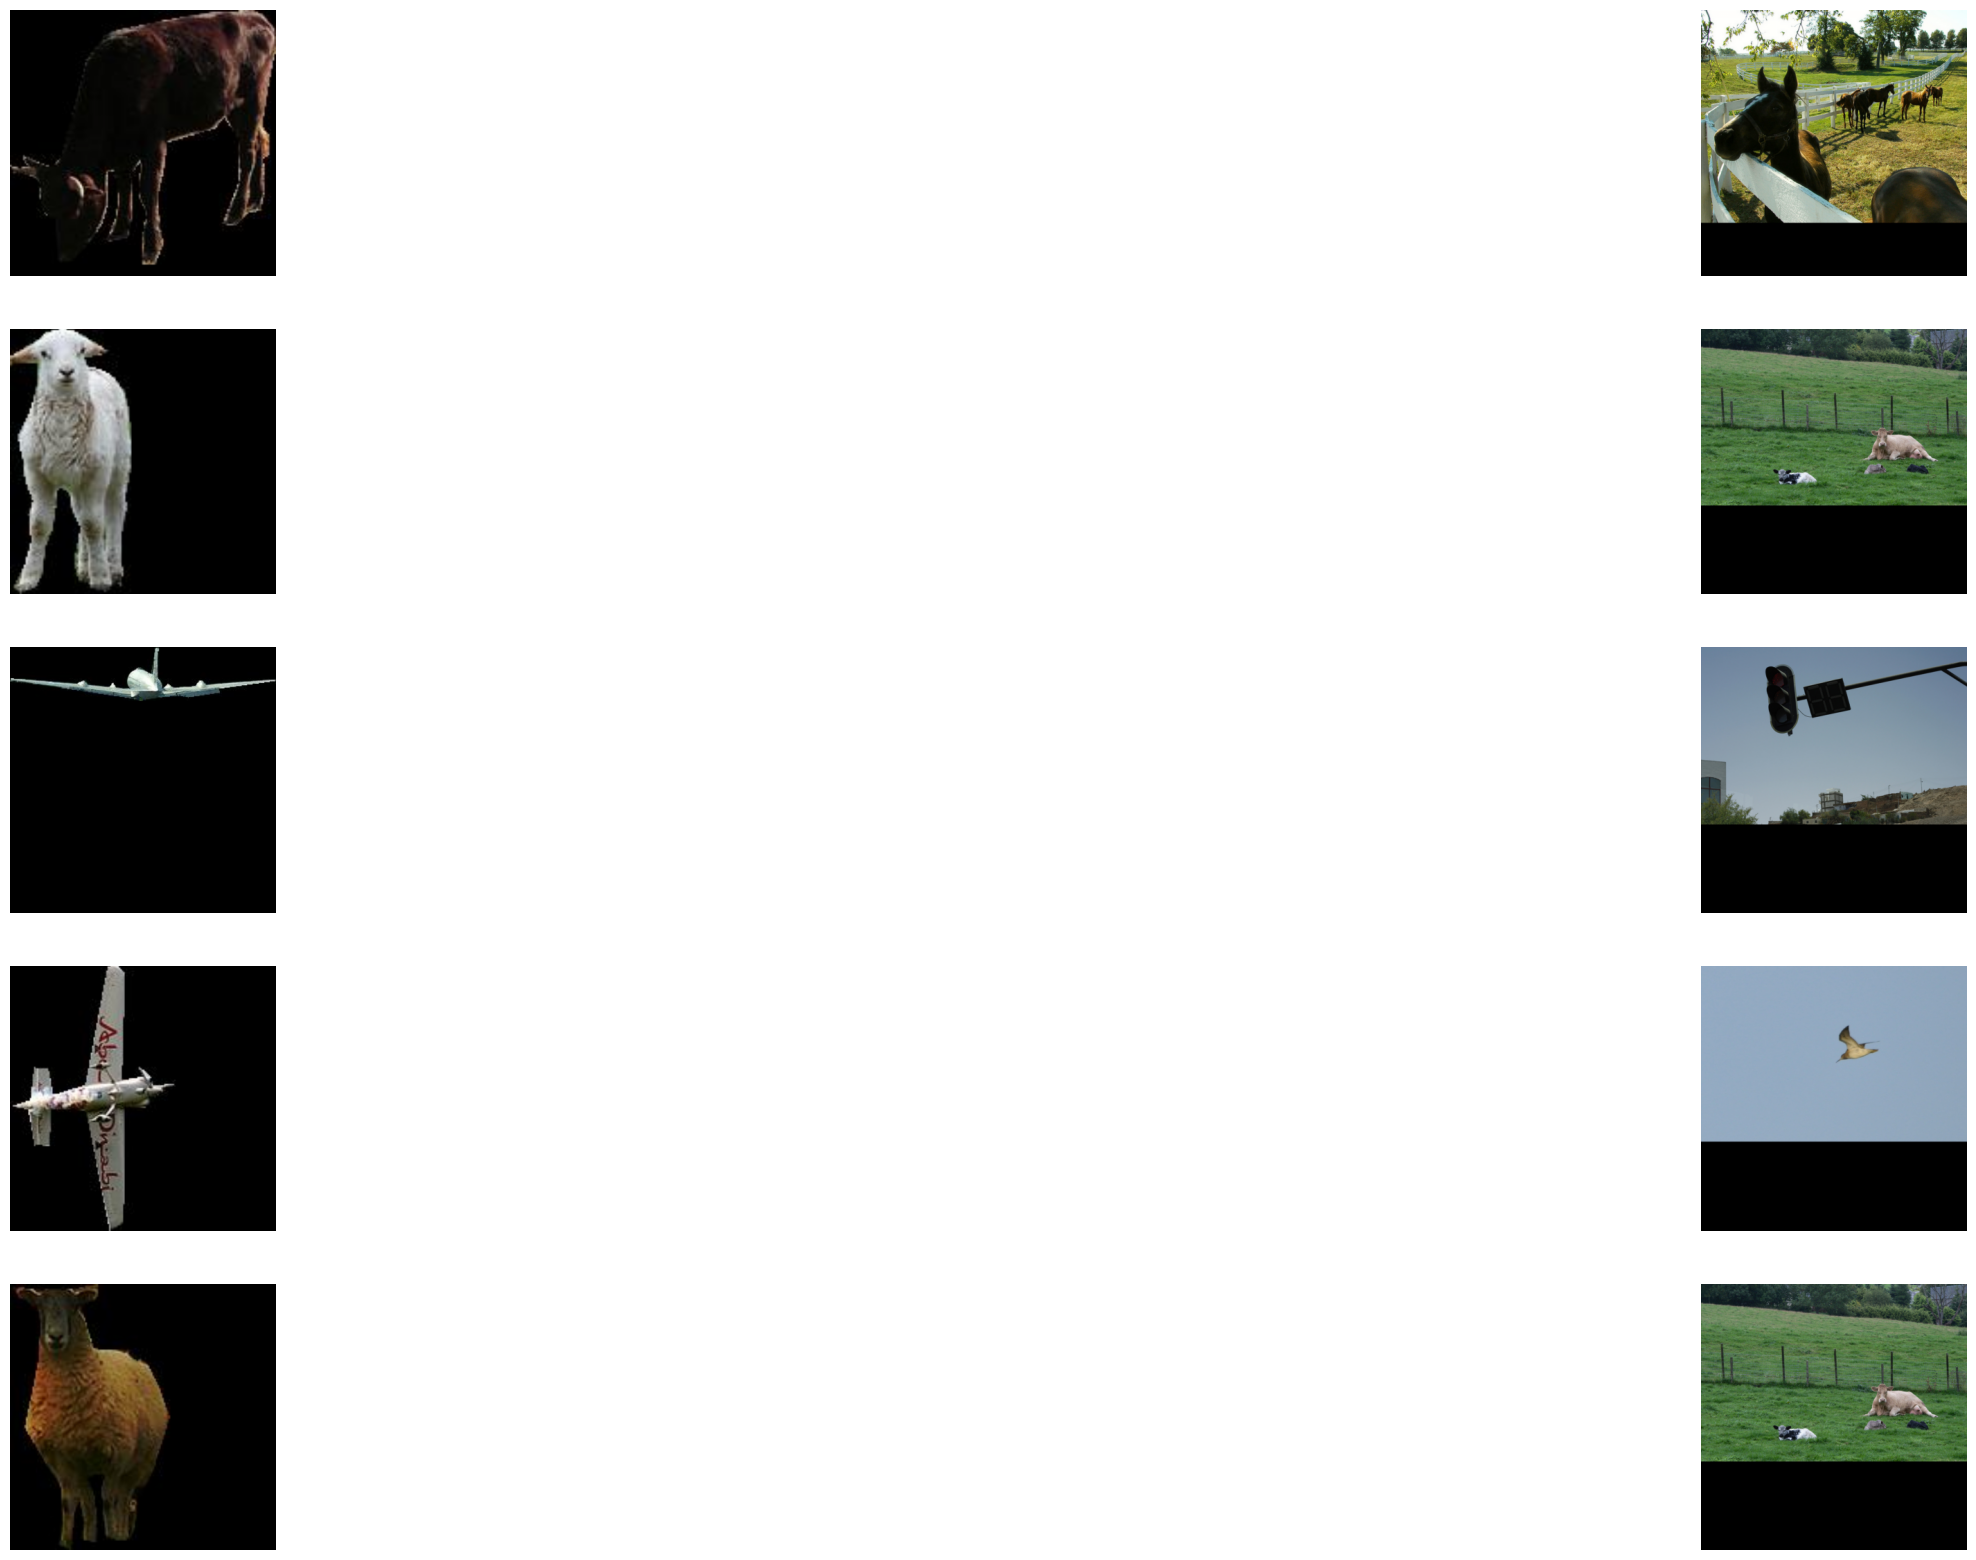

In [8]:
# visualize inputs after pre processed (2) testing pre processing steps
nrow = len(X)
ncol = 2
idx = 0
fig, axis = plt.subplots(nrow,ncol,figsize=(40,20))
for x in X:
    fg_img = x[3:, :, :]
    bg_img = x[:3, :, :]
    bg_img = show_normalized_image(bg_img.cpu())
    fg_img = show_normalized_image(fg_img.cpu())

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(fg_img)

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(bg_img)

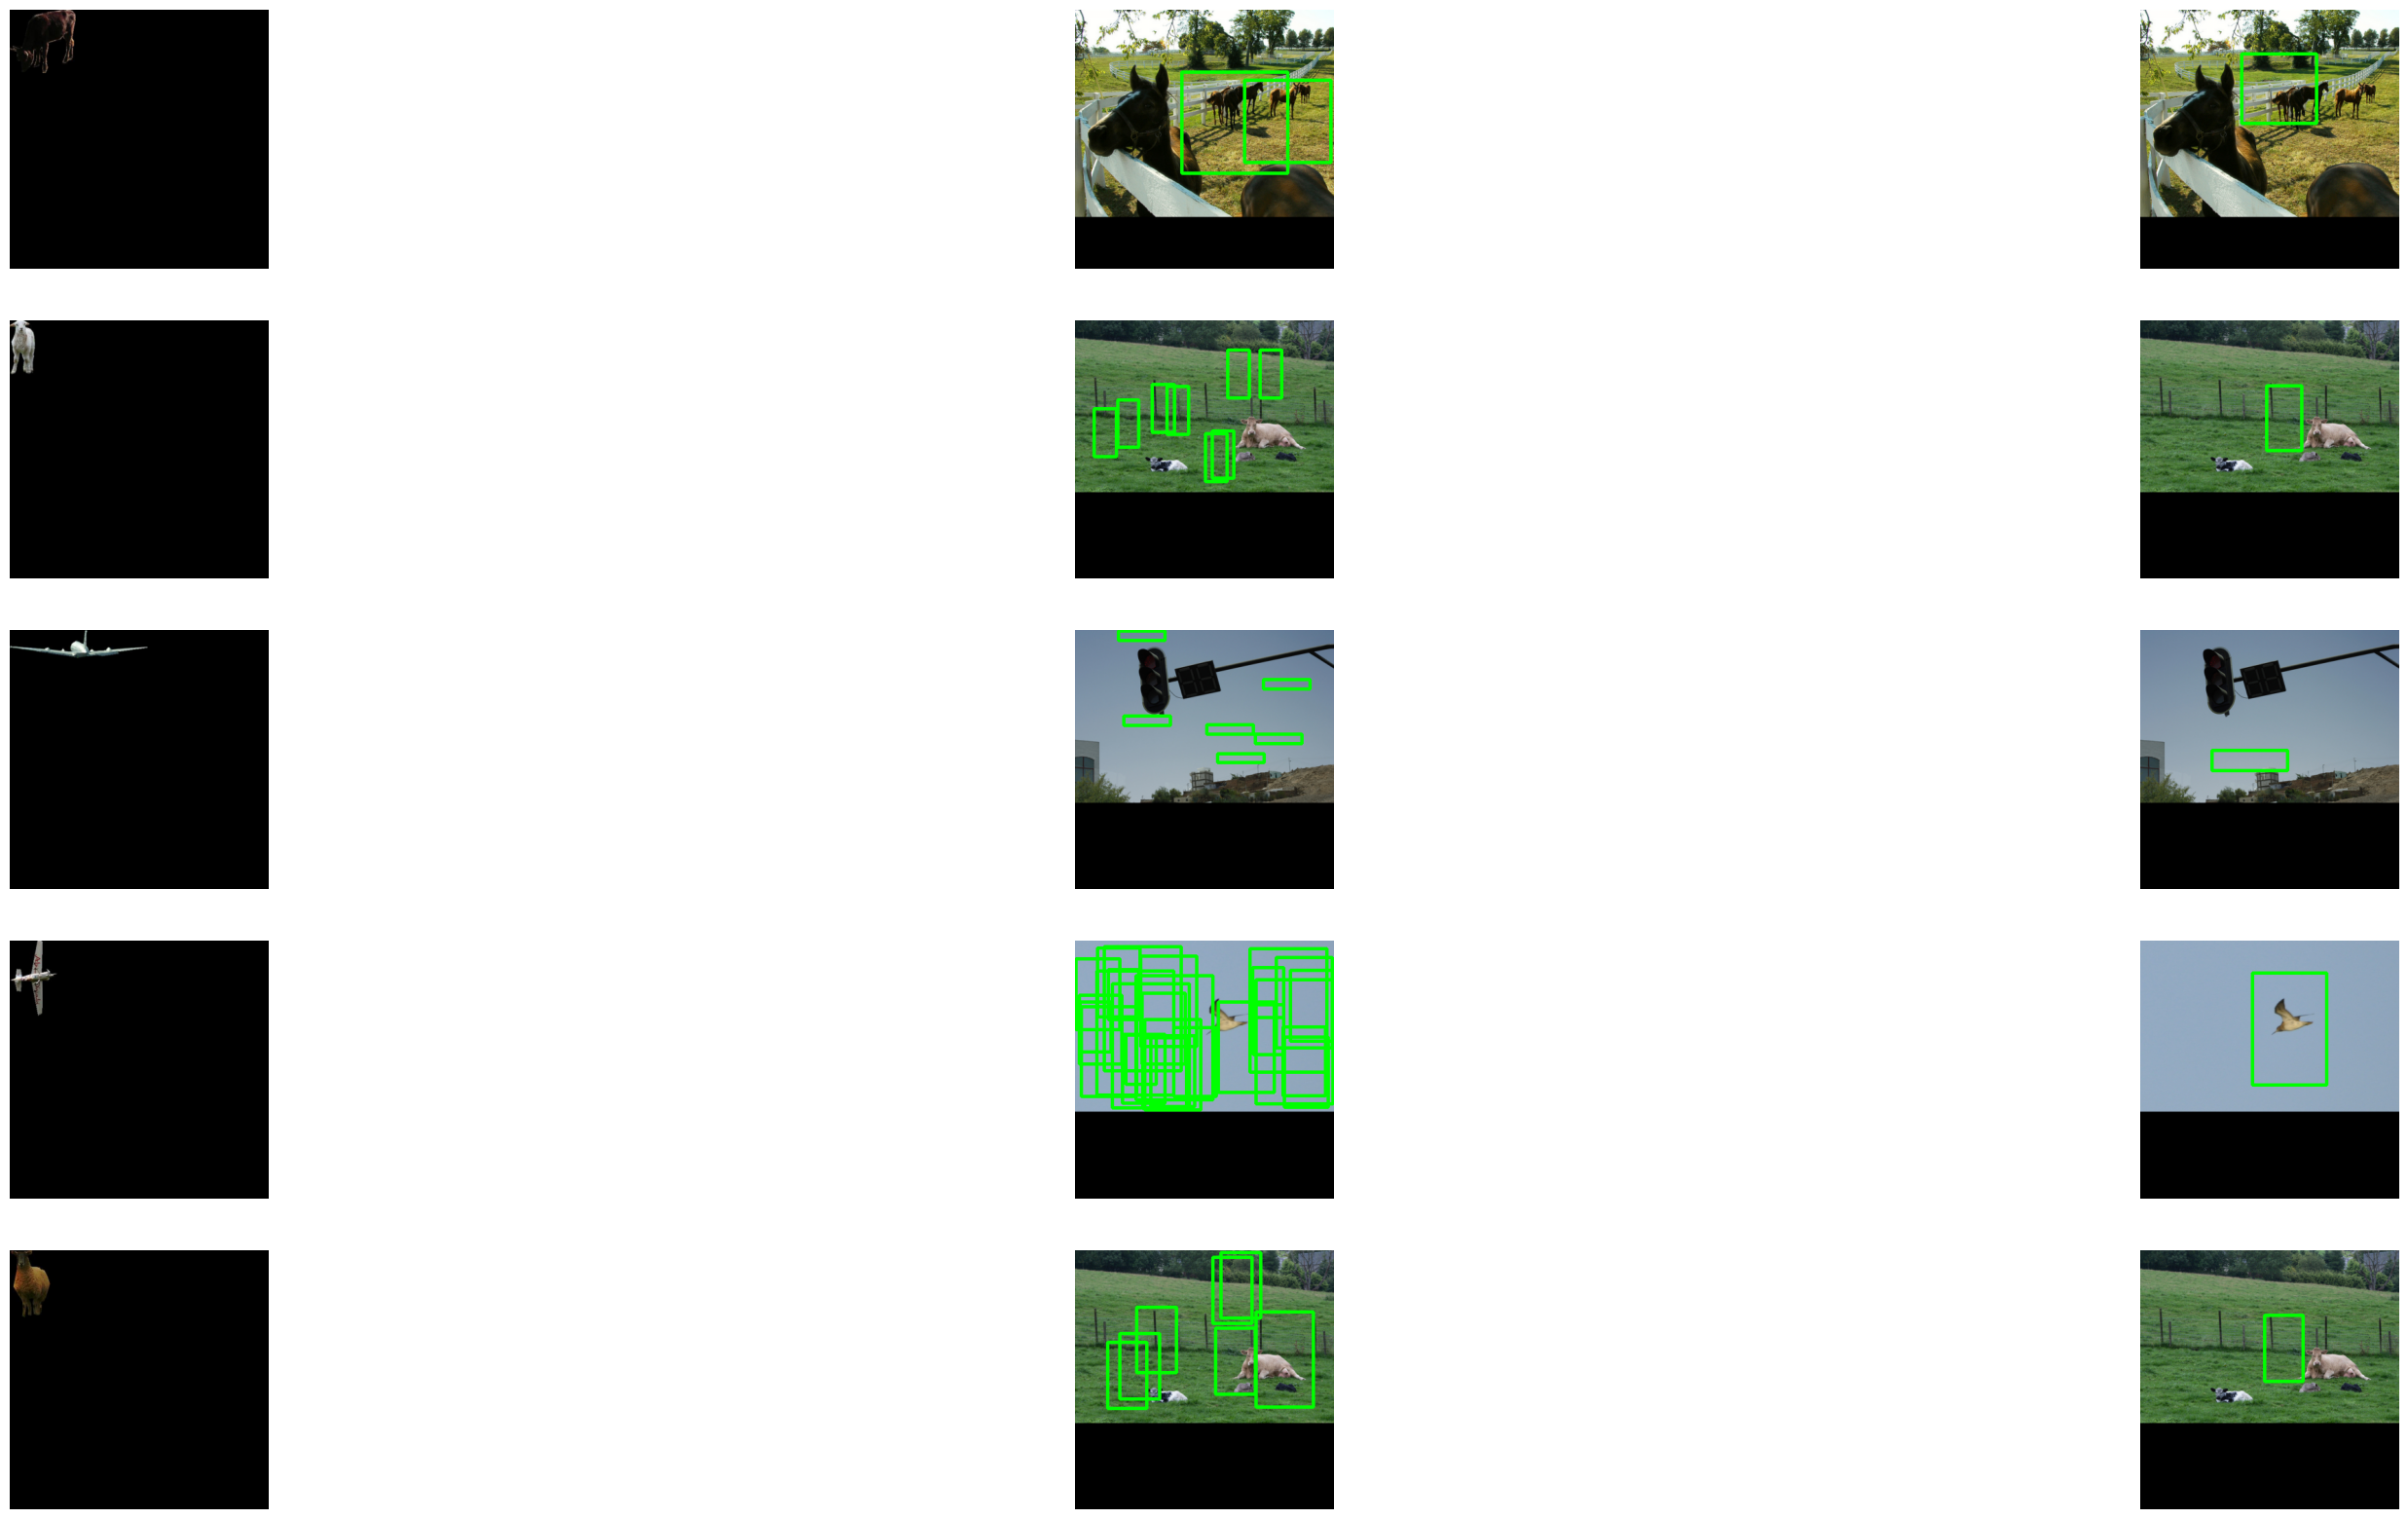

In [34]:
nrow = len(X)
ncol = 3
idx = 0

fig, axis = plt.subplots(nrow,ncol,figsize=(40,20))
for i in range(len(X)):
    fg_n, bg_n = n[i].split("c")
    fg_img = X[i][3:, :, :]
    bg_img = X[i][:3, :, :]    

    x = X[i]
    label = y[i]

    pred_img = bg_img[:,:,:]
    pred_img = show_normalized_image(pred_img.cpu())
    label_img = show_normalized_image(bg_img.cpu())
    fg_img = show_normalized_image(fg_img.cpu())

    for each_label in label:
        xmin = each_label[0].item()
        ymin = each_label[1].item()
        xmax = each_label[2].item()
        ymax = each_label[3].item()
        if xmin == float('inf'):
            break
        xmin,ymin,xmax,ymax = [int(x) for x in [xmin,ymin,xmax,ymax]]
        label_img = cv2.rectangle(label_img,(xmin,ymax),(xmax,ymin),(0,255,0),3)

    pred = trained_pred[i]
    
    xmin = pred[0].item()
    ymin = pred[1].item()
    xmax = pred[2].item()
    ymax = pred[3].item()
    xmin,ymin,xmax,ymax = [int(x) for x in [xmin,ymin,xmax,ymax]]
    pred_img = cv2.rectangle(pred_img,(xmin,ymax),(xmax,ymin),(0,255,0),3)
    
    #bg_img = bg_img.cpu().type(torch.uint8).permute(1, 2, 0).numpy()
    #fg_img = fg_img.cpu().type(torch.uint8).permute(1, 2, 0).numpy()

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(fg_img)

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(label_img)

    idx += 1
    plt.subplot(nrow, ncol, idx)
    plt.axis("off")
    plt.imshow(pred_img)


In [36]:
b_vit = torchvision.models.vit_b_16(weights="IMAGENET1K_SWAG_E2E_V1") 

In [38]:
b_vit.heads = torch.nn.Identity()

In [43]:
dataset_path = ds_path
label_dir = dataset_path + "new_alt_test_label.csv"
img_dir = dataset_path + "background"
obj_dir = dataset_path + "foreground"
transform = vit_transform

In [44]:
test_dataset = OPADataset(label_dir, img_dir, obj_dir, transform=transform, target_transform=None)

In [47]:
test_dataloader = DataLoader(test_dataset, batch_size=1)

In [52]:
for X,y,n in test_dataloader:
    X = X[:, :3, :, :]
    print(X.shape)
    pred = b_vit(X)
    break

torch.Size([1, 3, 384, 384])


In [65]:
pred.shape

torch.Size([1, 768])

In [37]:
b_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [34]:
obj_fe = torchvision.models.efficientnet_v2_s(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /home/jay/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100.0%


In [60]:
obj_fe

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [59]:
obj_fe.classifier = torch.nn.Identity()

In [62]:
obj_fe.to(gpu)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [69]:
for X,y,n in test_dataloader:
    X = X[:, :3, :, :]
    print(X.shape)
    fg_pred = obj_fe(X)
    break

torch.Size([1, 3, 384, 384])


In [75]:
X[0].shape

torch.Size([3, 384, 384])

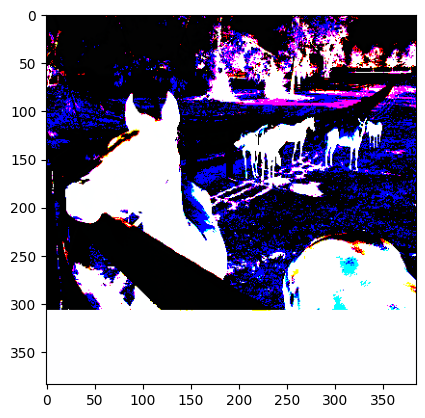

In [79]:
plt.imshow(X[0].cpu().type(torch.uint8).permute(1, 2, 0).numpy())

In [64]:
fg_pred.shape

torch.Size([1, 1280])

In [3]:
!ls dataset/OPA/new_OPA/

background	      lraspp.ipynb	       output
composite	      max		       readme.txt
create_label.ipynb    max.zip		       test.png
data_wrangling.ipynb  new_alt_test_label.csv   test_set.csv
density.ipynb	      new_alt_train_label.csv  train_set.csv
foreground	      new_test_label.csv       uniform
label.zip	      new_train_label.csv      weighted
lraspp_backup.ipynb   old_label


In [4]:
ds_path = "dataset/OPA/new_OPA/"

In [13]:
sample_fg_name = ["airplane/156417.jpg", "airplane/156529.jpg",
                  "apple/1047228.jpg", "banana/1041510.jpg",
                  "banana/1041620.jpg", "chair/101090.jpg"]

In [14]:
fg_imgs = []
for n in sample_fg_name:
    img_n = os.path.join(ds_path,"foreground",n)
    fg_imgs.append(decode_image(img_n).type(torch.float32))

In [29]:
resized_fg_imgs = [pad_to_n(torchvision.transforms.Resize((384,))(img),384) for img in fg_imgs]

In [19]:
def show_img(imgs):
    nrow = len(imgs)
    ncol = 1
    idx = 0
    fig, axes = plt.subplots(nrow, ncol, figsize=(10,10*nrow))
    for img in imgs:
        idx += 1
        img = img.type(torch.uint8).permute(1, 2, 0).numpy()
        plt.subplot(nrow, ncol, idx)
        plt.imshow(img)


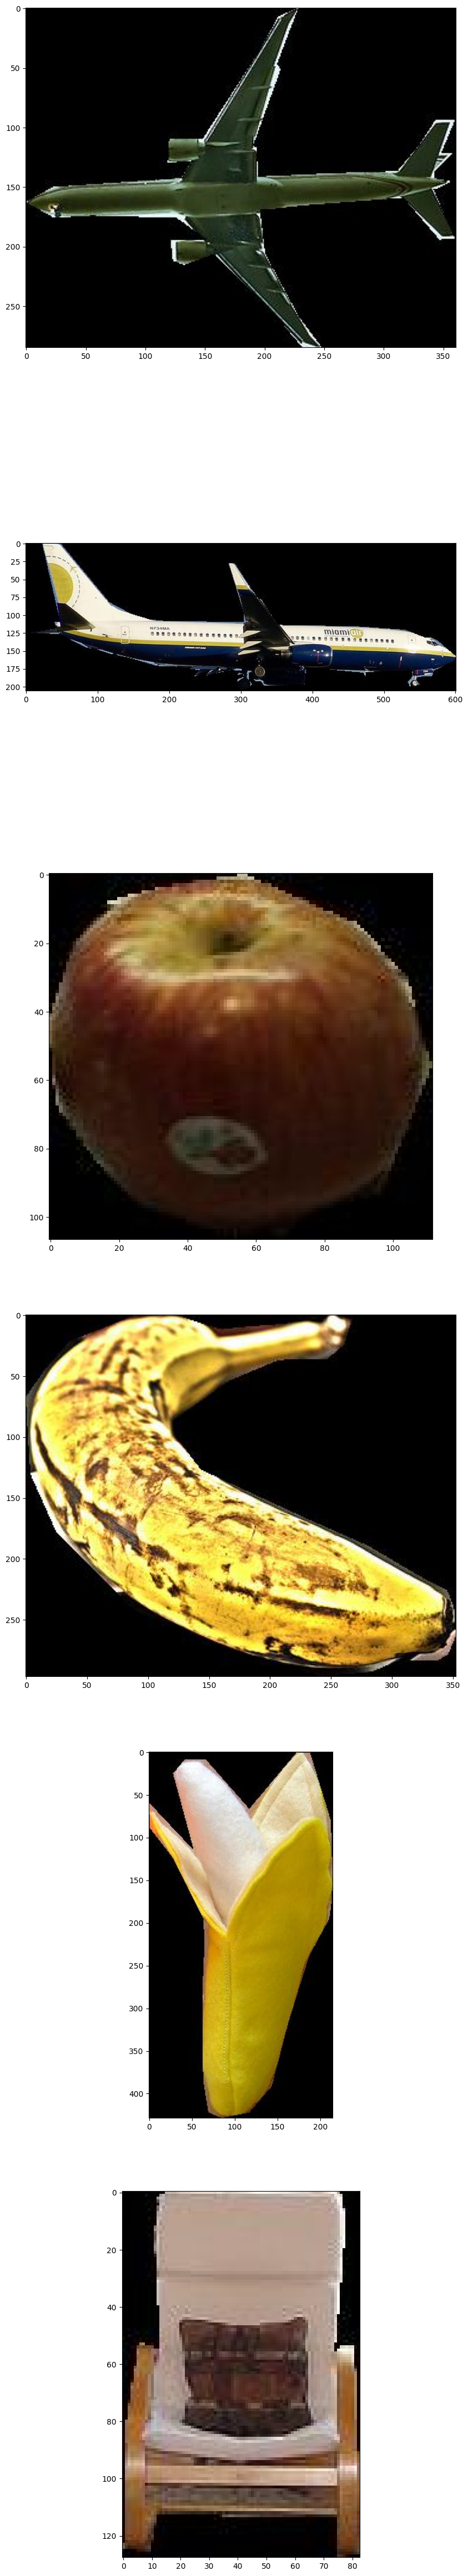

In [30]:
show_img(fg_imgs)

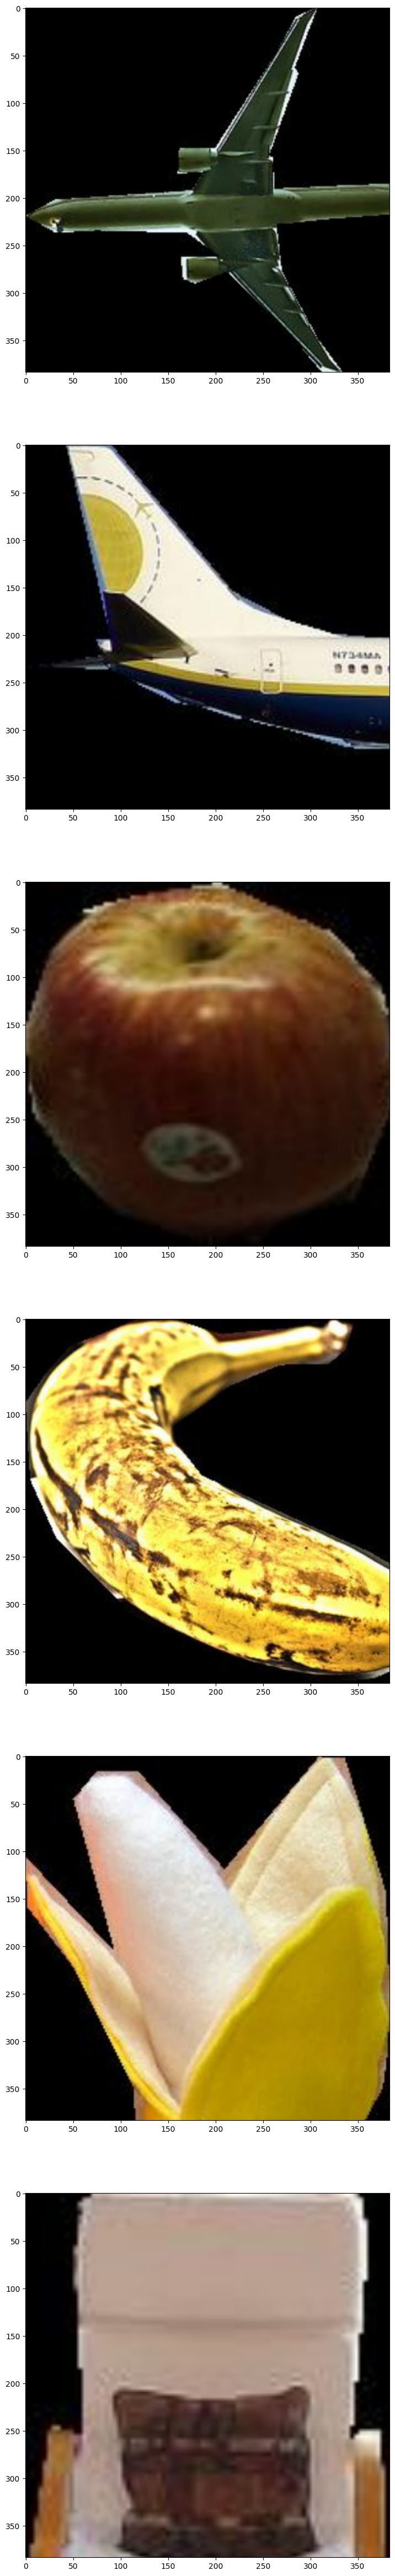

In [31]:
show_img(resized_fg_imgs)